In [33]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
from datetime import datetime

pd.set_option('display.max_columns', None)  # 모든 컬럼 다 보이게 설정

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from scipy.stats import shapiro

# 지리 라이브러리
from geopy.distance import geodesic

# 전처리용
from itertools import combinations

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 윈도우용 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')  # 말굿 고딕 (Windows 기본 한글 폰트)
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 머신러닝 - 전처리, 모델, 평가
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 머신러닝 알고리즘 (필요에 따라 선택적으로 추가)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, XGBRegressor

# 텍스트 처리
from rapidfuzz import process, fuzz

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# # # 딥러닝 (선택사항)
# import tensorflow as tf
# from tensorflow import keras
# from keras.models import Sequential
# from keras.layers import Dense, Dropout

# 모델 해석
import shap



# dataset

In [66]:
from generate_dataset import simulate_corsia_mrv_fuel_burn, test_sum
df = simulate_corsia_mrv_fuel_burn()
df = df[df['year'] == 2019][['airline_id', 'operator_state', 'region', 'year','fuel_burn_tonnes']]
df.columns = ['airline_id', 'operator_state', 'region', 'year', 'FB']
df

,airline_id,operator_state,region,year,FB
0,AL0001,India,APAC,2019,1.669232e+06
7,AL0002,France,EUR,2019,2.904625e+05
14,AL0003,Brazil,LAM,2019,5.203632e+05
21,AL0004,"Korea, Rep.",APAC,2019,1.010770e+06
28,AL0005,United States,NAM,2019,8.916956e+04
...,...,...,...,...,...
4165,AL0596,China,APAC,2019,3.013853e+05
4172,AL0597,"Korea, Rep.",APAC,2019,1.139743e+05
4179,AL0598,Singapore,APAC,2019,3.401084e+05
4186,AL0599,Canada,NAM,2019,5.582960e+05


<Axes: xlabel='FB', ylabel='Count'>

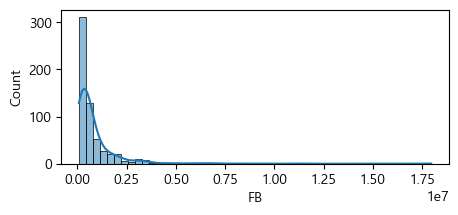

In [67]:
# 2019년 연도별 항공사 연료소모량 분포 시각화
plt.figure(figsize=(5,2))
# sns.histplot(df, x='FB', bins=50, hue='region', kde=True, multiple='stack' )
sns.histplot(df, x='FB', bins=50, kde=True)
# 일부 대형 항공사와 소규모 항공사가 존재

# model

## emission Factor

$EF_i = (1 - s_i \lambda_i)\cdot EF_{fossil}$

In [68]:
 # Emission Factor
# assume fixed
# 향후 논문에서는 saf price, tech 발전 등을 반영한 동적 모형 고려 가능
ef_fossil = 3.16  # kg CO2 per kg fuel  ## base : 3.16 kg CO2 per kg fuel
lambda_saf = 0.8  # kg CO2 per kg fuel  ## lambda saf:  life cycle reduction : 0.8 kg CO2 per kg fuel assumption
rate_saf = 0.02  # 2% SAF use from 2025   ## saf use: 2025 2% fixed assumption  
ef = (1 - rate_saf * lambda_saf ) * ef_fossil  # adjusted emission factor
print('effective emission factor:', ef)

effective emission factor: 3.10944


## economic grow

${FB}_{i,t}\ =\ {FB}_{i,0}\ \cdot\ \prod_{\tau=1}^{t}g_{i,\tau}\ ,\ \ g_{i,\tau}\ ~\ \mathcal{D}_i(\mu_i,\sigma_i^2)$

In [73]:
# Define growth scenarios 
economic_growth = {
    "low"   : {"g_mean": 0.01, "g_sd": 0.03},
    "normal": {"g_mean": 0.03, "g_sd": 0.04},
    "high"  : {"g_mean": 0.05, "g_sd": 0.05}
    }

## Carbon Offset and Offset cost
$O_{i,t}=max(E_{i,t}-{\overline{E}}_i , 0 )$

In [74]:
df_offset = df.copy()
df_offset['offset'] = df_offset['FB']

In [75]:
# Define carbon price scenarios
carbon_price = {
    "low": {"p_mean": 50, "p_sd": 15},
    "normal": {"p_mean": 80, "p_sd": 20},
    "high": {"p_mean": 120, "p_sd": 30}
    }

In [ ]:
# scenario dictionary
scenarios = {
    "economic_growth": economic_growth,
    "carbon_price": carbon_price
    }
scenarios